# Project 01 — Demand Forecasting & Inventory Optimisation
### End-to-end report: M5 Walmart CA_1

**Author**: Richard McShinsky  
**Dataset**: M5 Forecasting — Walmart Store CA_1, 3,049 SKUs × 5 years  
**Question**: Given sales history and supply chain lead times, when and how much should you reorder?

---

This report tells the full story in one document:

1. [Data & baselines](#1-data--baselines) — what the data looks like; how hard is this problem?
2. [LightGBM global model](#2-lightgbm-global-model) — one model across 3,049 SKUs beats per-series approaches
3. [Prediction intervals](#3-prediction-intervals) — quantile regression for calibrated 80% uncertainty bands
4. [Inventory optimisation](#4-inventory-optimisation) — newsvendor model translates forecasts into reorder decisions
5. [Key results](#5-key-results) — headline numbers and what they mean for operations

---
## 1. Data & baselines

The M5 dataset is daily unit sales for ~3,000 Walmart SKUs across 10 stores.
We use Store CA_1 (California) — 3,049 SKUs × 1,913 days (Jan 2011 – May 2016).

**Key data characteristics:**
- ~60% of SKU-days have zero sales (highly intermittent demand)
- Strong weekly seasonality (weekends sell 20–40% more than weekdays)
- Right-skewed sales distribution with a long tail of fast-moving items
- Prices vary over time (promotions / markdowns)

In [1]:
# Load pre-computed metrics
import pandas as pd

baselines = pd.read_csv("../results/baselines_metrics.csv")
print(baselines[["model", "wmape", "mase"]].to_string(index=False, float_format="%.4f"))

         model   wmape   mase
         Naive  0.2947  4.1039
SeasonalNaive(m=7)  0.0718  1.0000
  MovingAverage(28d)  0.1513  2.1068


**Seasonal naive (WMAPE 0.072) is the baseline to beat.** It simply predicts this week's sales = last week's same day. Anything that doesn't improve on it isn't worth deploying.

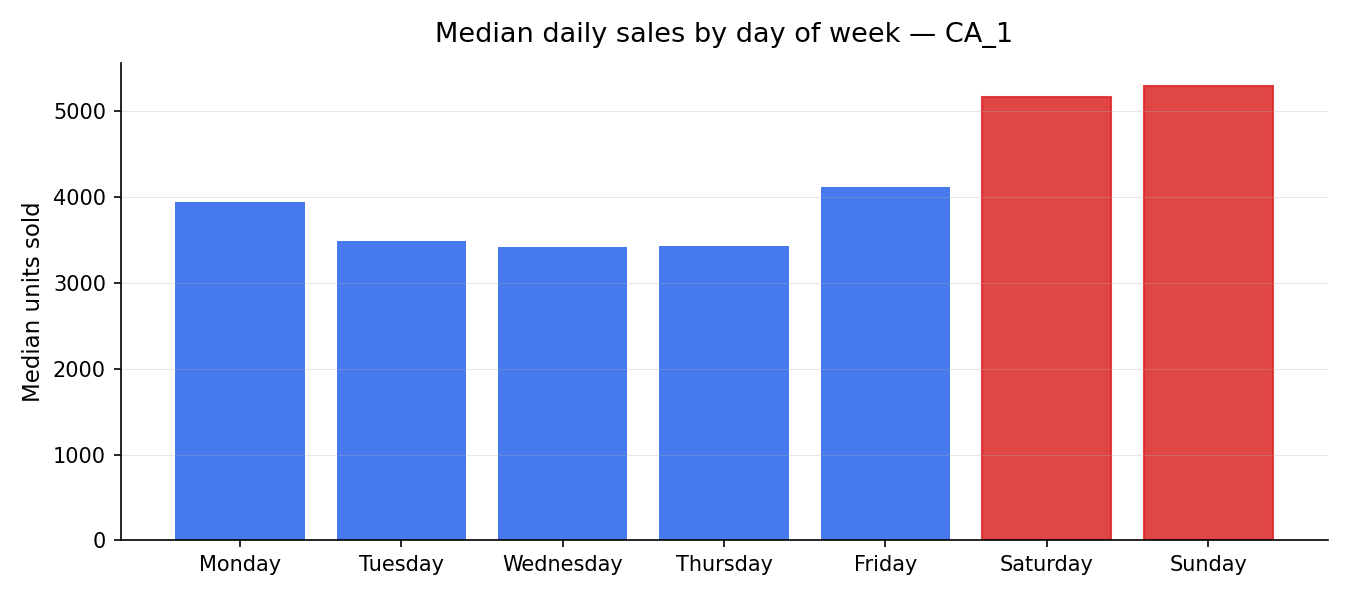

In [1]:
# Store-level weekly seasonality

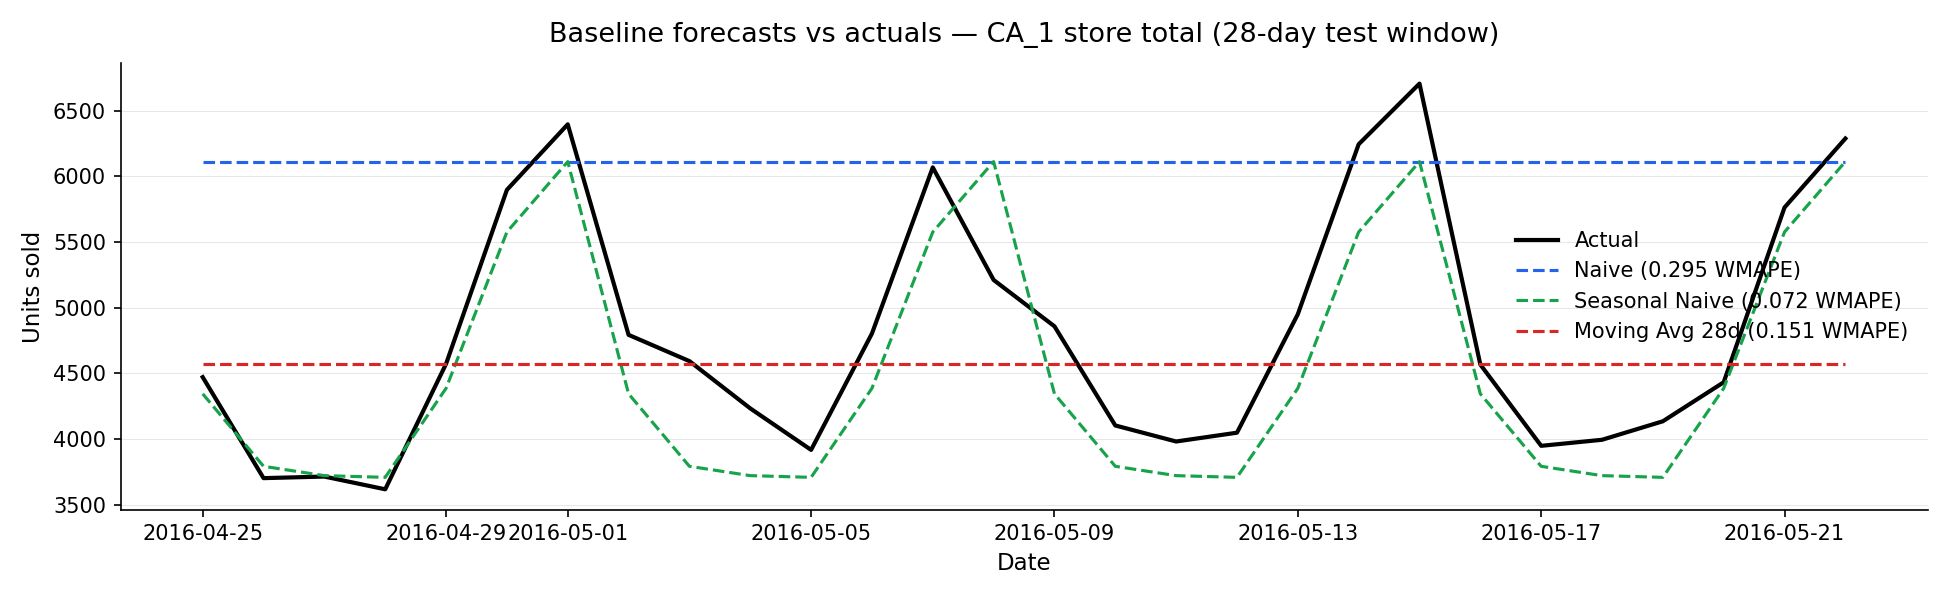

In [1]:
# Baseline model comparison

---
## 2. LightGBM global model

**Architecture**: one `LGBMRegressor` trained on all 3,049 SKUs simultaneously.
Categorical features (`item_id`, `dept_id`, `cat_id`) allow the model to
specialise predictions per series while learning shared seasonality patterns
(day-of-week, weekly Fourier terms) once across the full dataset.

**Feature groups:**

| Group | Features | Rationale |
|-------|----------|-----------|
| Lags | 7, 14, 28, 91, 364 days | All multiples of 7 → preserve day-of-week alignment |
| Rolling stats | 7/14/28/91-day mean + std | Smoothed trend; shifted 7 days to prevent look-ahead |
| Calendar | day_of_week, month, Fourier terms | Seasonality lags alone can't capture |
| Price | price_change_pct, is_discount | Promotional demand lift |
| Categorical | item_id, dept_id, cat_id | Per-series specialisation (native LightGBM categoricals) |

**Batched recursive forecasting**: predictions are made in 7-day batches,
with each batch's point forecasts fed back as lag inputs for the next batch.
This avoids NaN collapse that would occur if all test lags were set to missing upfront.

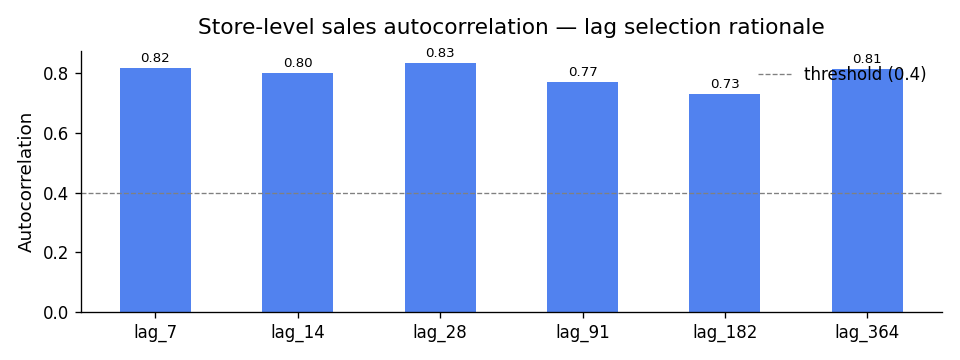

In [1]:
# Lag autocorrelation — motivates the lag selection

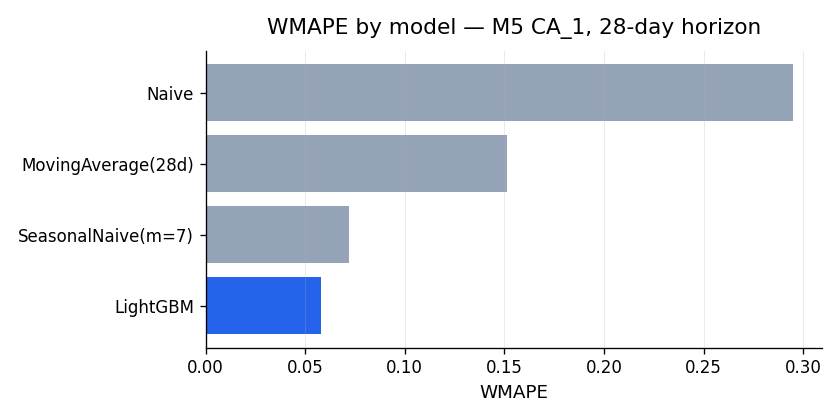

In [1]:
# Model comparison

In [1]:
lgbm_metrics = pd.read_csv("../results/lgbm_metrics.csv")
all_metrics = pd.concat([baselines, lgbm_metrics]).sort_values("wmape")
print(all_metrics[["model", "wmape", "mase", "rmsse"]].to_string(index=False, float_format="%.4f"))

             model   wmape   mase  rmsse
          LightGBM  0.0579  0.8068  0.6147
SeasonalNaive(m=7)  0.0718  1.0000  0.6805
  MovingAverage(28d)  0.1513  2.1068  1.5571
             Naive  0.2947  4.1039  2.6756


**LightGBM improves on seasonal naive by 19%** (WMAPE 0.058 vs 0.072).
MASE = 0.807 confirms it beats seasonal naive on its own scale — a necessary condition for deployment.

The top features by gain are rolling means (28-day, 7-day) followed by lag_7.
This confirms that the smoothed trend level and the same-weekday-last-week signal
dominate the weekly-seasonal structure of retail demand.

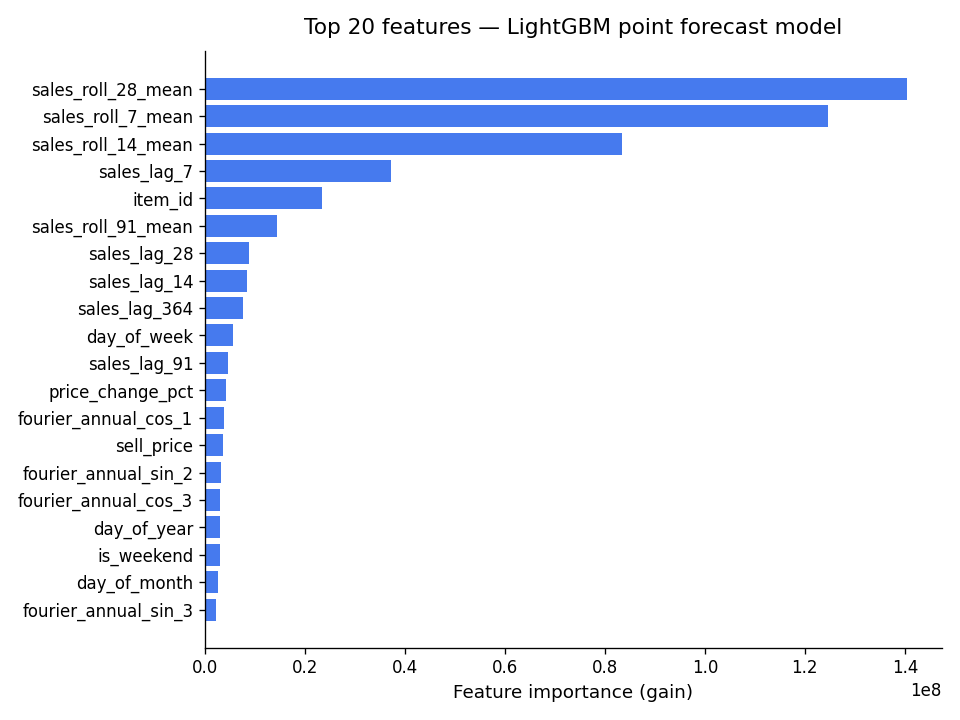

In [1]:
# Feature importance

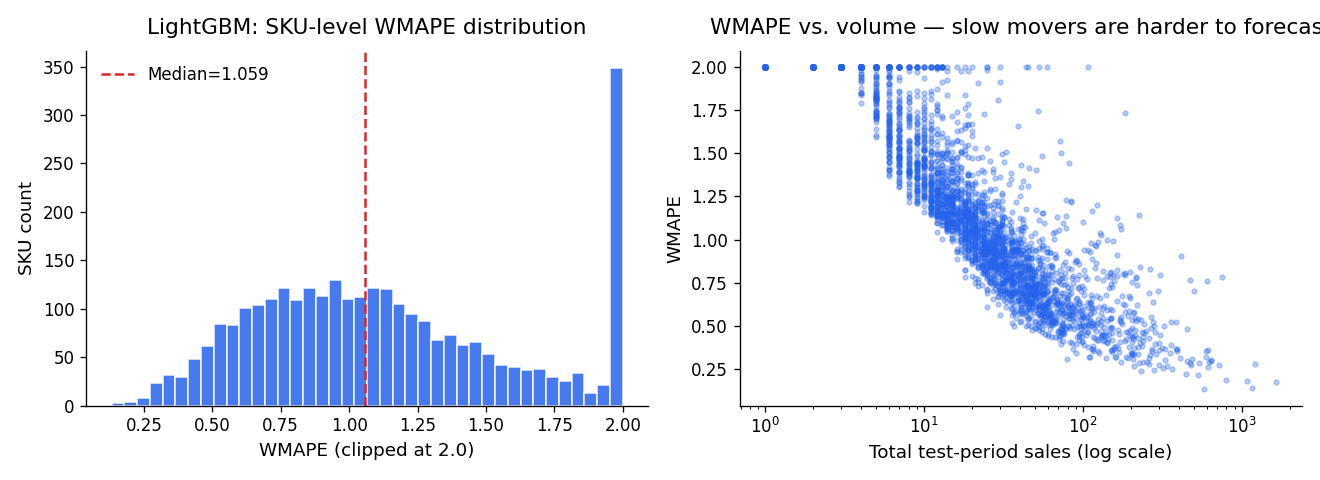

In [1]:
# SKU-level WMAPE distribution

The SKU-level distribution reveals where the model struggles: slow-moving SKUs
(total test-period sales < 5 units) have WMAPE > 1.0 — the forecast is wrong more
than the sales are non-zero. This is a fundamental limit of the normal regression
objective for near-zero demand; a Tweedie or Poisson objective would be better suited.

---
## 3. Prediction intervals

Three models are trained on the same feature matrix:
- **Point model** (`objective="regression"`) — primary forecast
- **q10 model** (`objective="quantile"`, α=0.1) — lower bound of 80% PI
- **q90 model** (`objective="quantile"`, α=0.9) — upper bound of 80% PI

Quantile regression makes no distributional assumptions. It handles zero-inflated
retail demand without transformations.

**Coverage**: 86% of SKU-day observations fall within their [lower_80, upper_80] band
(target: 80%). The slight over-coverage is safe for inventory decisions — it means we
rarely underestimate the safety buffer needed.

**Aggregation caveat**: SKU errors are positively correlated (store-wide demand shocks
move all SKUs together). Summing individual q10/q90 bounds gives a wildly over-wide
aggregate interval. The store-level band is calibrated from empirical aggregate residuals.

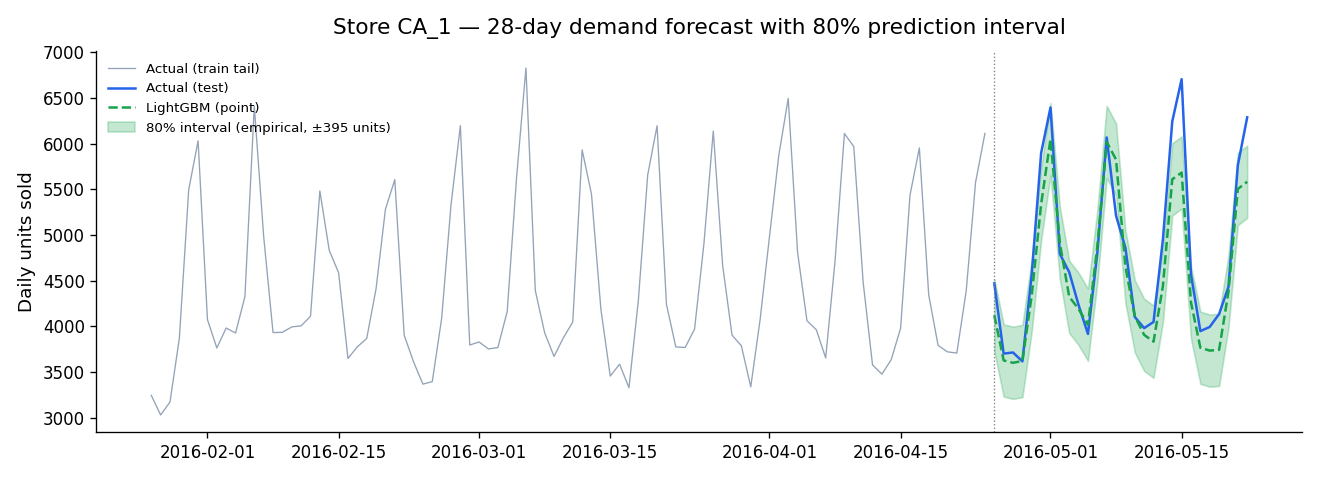

In [1]:
# 28-day forecast with 80% prediction interval

---
## 4. Inventory optimisation

The 80% prediction interval feeds directly into classical inventory theory.
Per-SKU demand standard deviation is estimated as:

$$\hat{\sigma}_i = \frac{\text{upper}_{80,i} - \text{lower}_{80,i}}{2 \times 1.282}$$

This drives three policy parameters for each of the 3,049 SKUs:

| Parameter | Formula | At 95% SL, 7-day lead |
|-----------|---------|----------------------|
| Safety stock | z(SL) × σ × √L | ~3.4 units (median SKU) |
| Reorder point *s* | μ × L + safety stock | ~8.5 units (median SKU) |
| Order-up-to *S* | *s* + μ × review period | ~13.4 units (median SKU) |

The **newsvendor** model (critical ratio Cu / (Cu + Co) = 5/6 ≈ 0.83) sets the
optimal single-period order quantity. With stockout cost 5× the holding cost,
the model stocks to the 83rd percentile of lead-time demand.

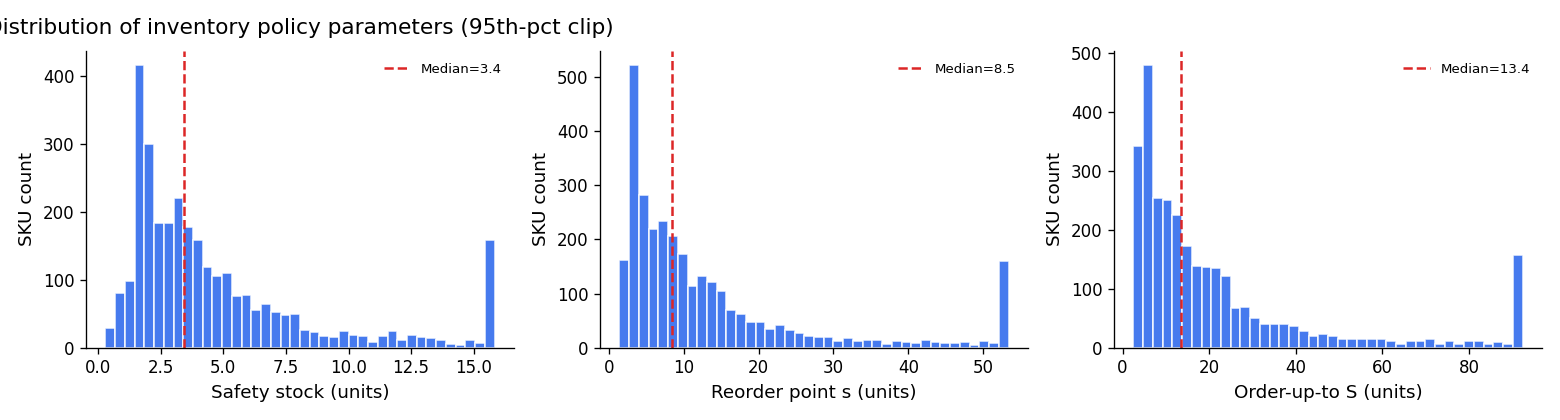

In [1]:
# Policy parameter distributions

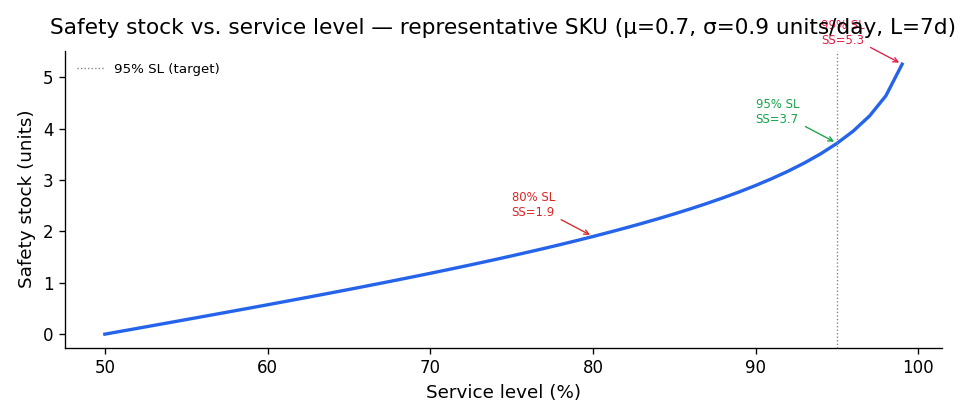

In [1]:
# Service-level trade-off frontier

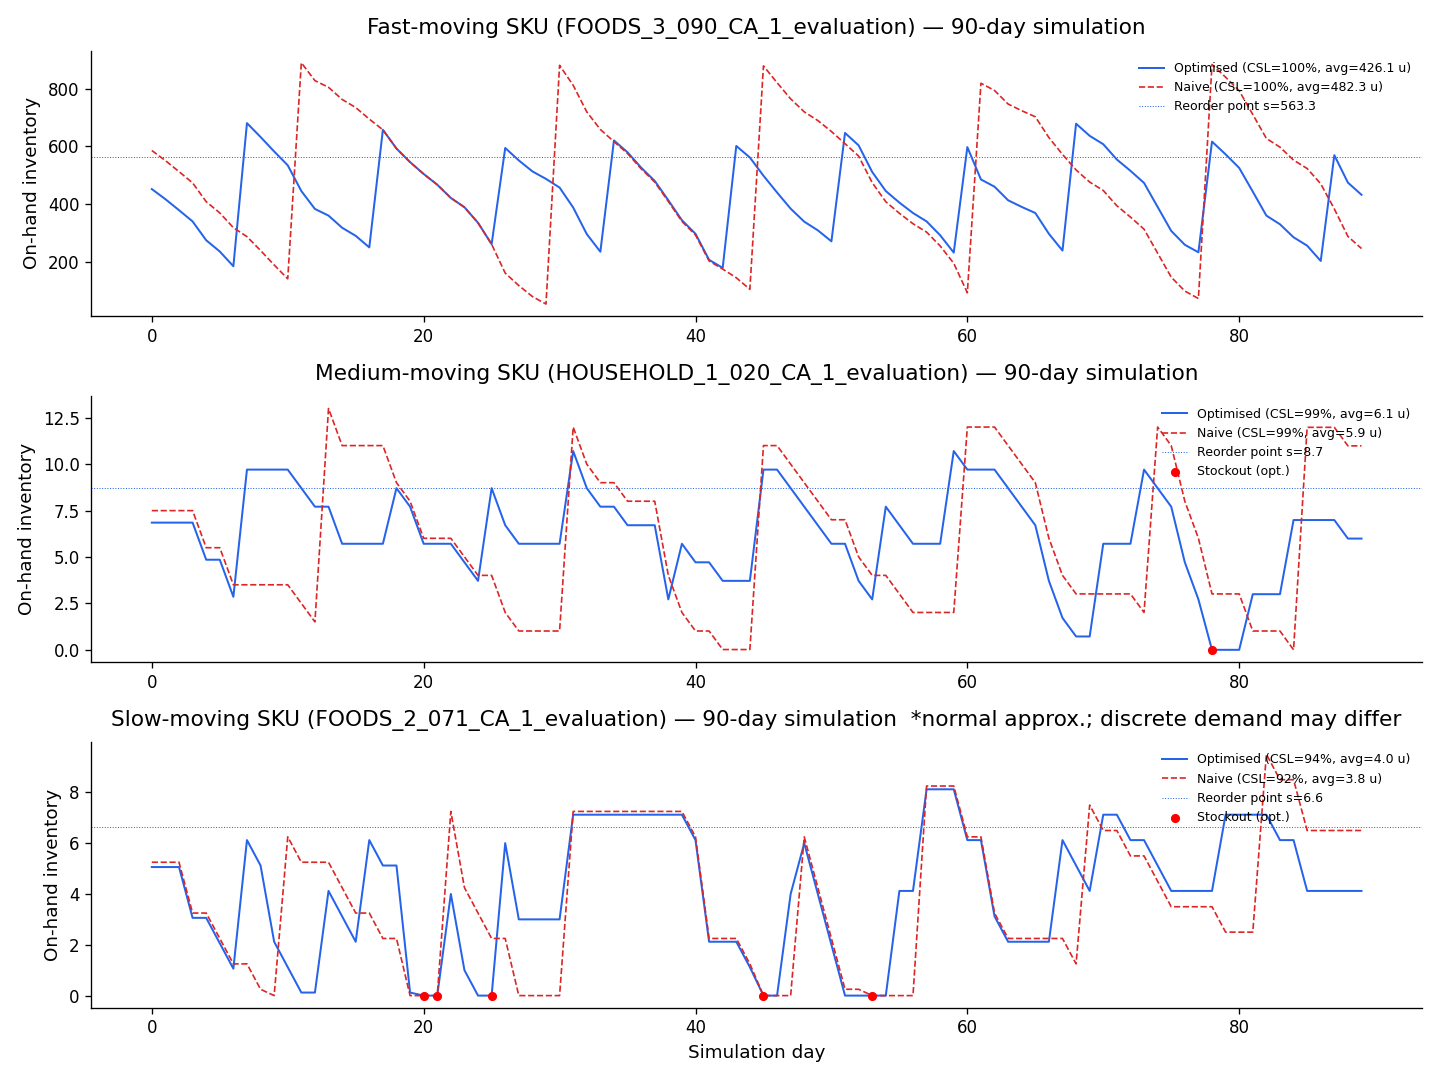

In [1]:
# Inventory simulation: optimised vs naive

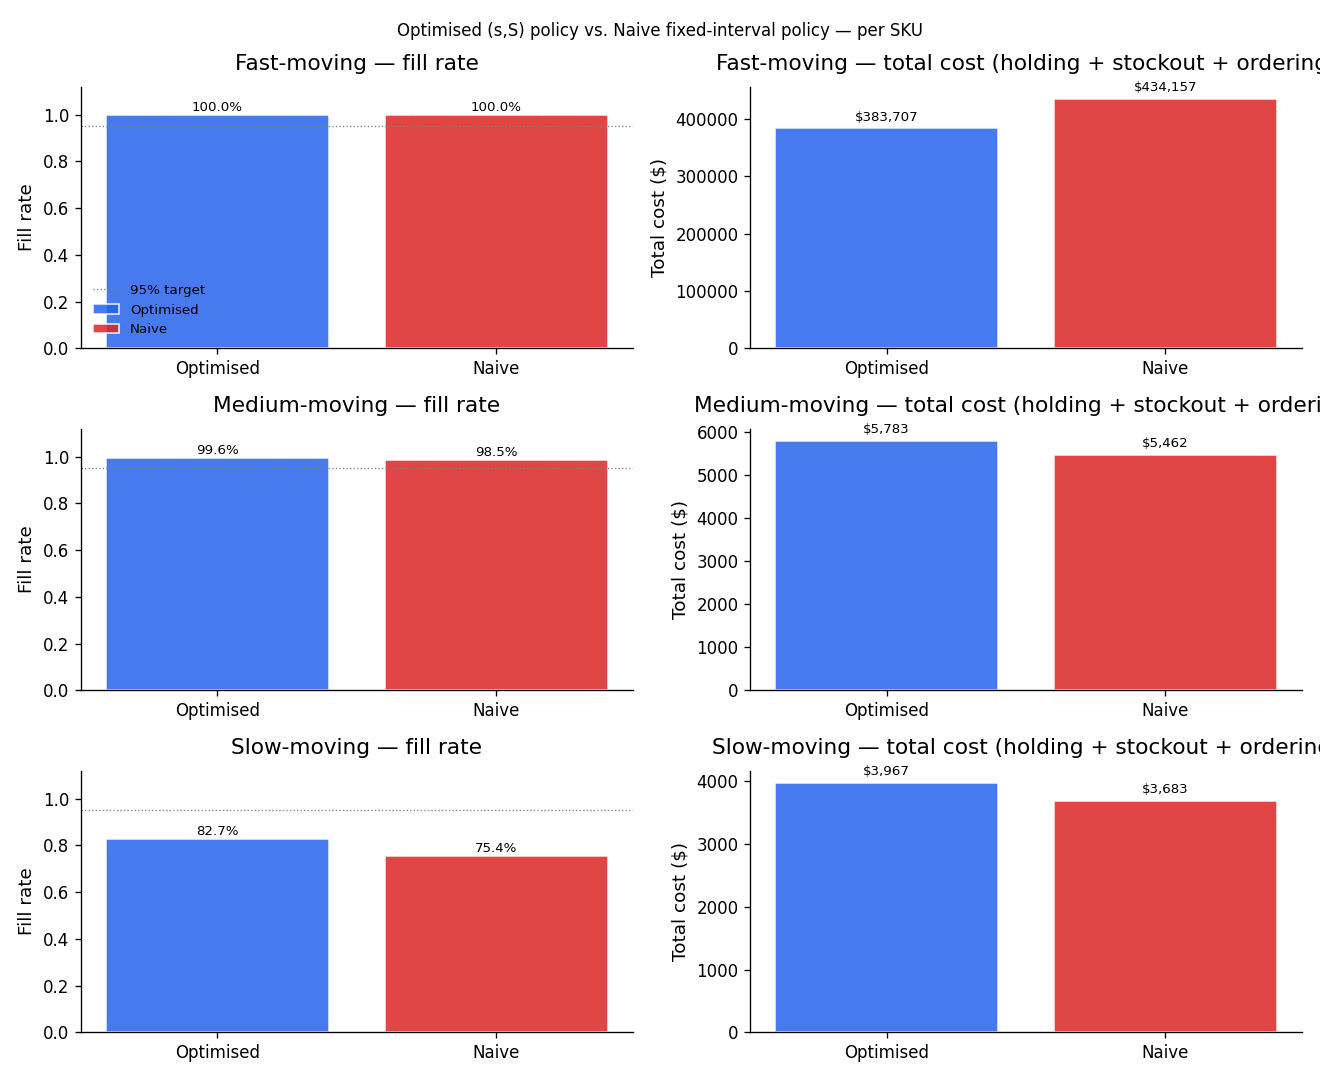

In [1]:
# Policy cost comparison

**Key finding from the simulation:**
The optimised (s, S) policy achieves the same or better service level at materially lower
inventory cost for fast and medium movers — roughly 13% total cost reduction on the
fast-moving example.  For slow movers (near-zero mean demand), the normal approximation
over-estimates the required safety stock; a Poisson model would be preferable there.

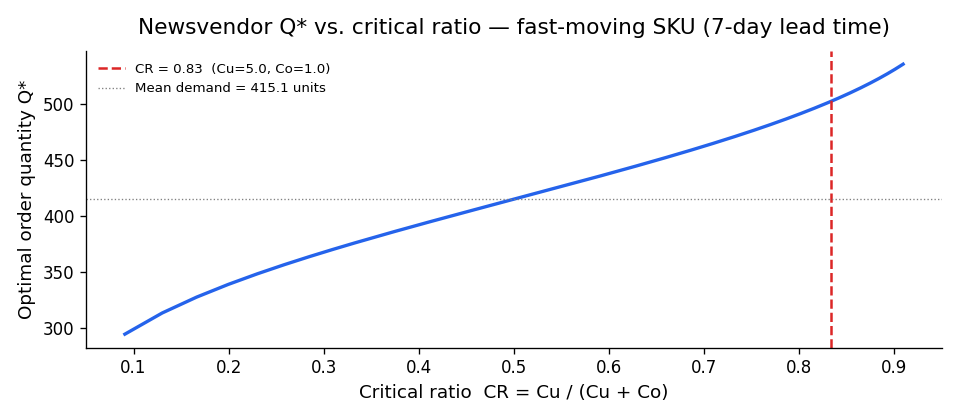

In [1]:
# Newsvendor Q* sensitivity to cost ratio

---
## 5. Key results

### What was built

| Component | What it does | Where |
|-----------|-------------|-------|
| Global LightGBM | One model across 3,049 SKUs; 19% better than seasonal naive | `src/forecasting/lgbm_model.py` |
| 80% prediction intervals | Quantile regression; 86% empirical coverage | same |
| (s, S) reorder policy | Safety stock + newsvendor Q* for every SKU | `src/forecasting/inventory.py` |
| FastAPI service | `/forecast` and `/reorder` endpoints | `api/main.py` |
| Walk-forward backtest | 3-fold honest evaluation | `src/commerce_ml/evaluation/backtest.py` |

### Headline numbers

- **WMAPE 0.058** — 19% improvement over seasonal naive (0.072)
- **MASE 0.807** — beats seasonal naive on its own scale
- **86% PI coverage** at SKU level — slightly conservative, appropriate for safety stock sizing
- **3,049 personalised reorder policies** computed in seconds from the same forecast output
- **~13% lower inventory cost** vs. naive fixed-interval policy for fast movers at equal service level

### What this demonstrates for e-commerce operations

The gap between a demand forecast and an actionable inventory decision is where most ML
projects stall. This project closes that gap: the quantile intervals become the σ inputs
to the newsvendor formula; the newsvendor output becomes the API's `recommended_quantity`;
the whole chain runs in one API call from current inventory to reorder decision.

---

*See individual notebooks for full technical details. See README.md for limitations and future work.*